In [36]:
!curl https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -o input.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1089k  100 1089k    0     0  5669k      0 --:--:-- --:--:-- --:--:-- 5702k


In [44]:
import torch.nn.functional as F
x = torch.rand(1, 1, 2, 2)
Phi = torch.zeros(1, 1, 4, 2)

print(x.shape)
# pad x with zeros along the 3nd dimension to match the size of Phi
x = F.pad(x, (0,0,0,Phi.shape[-2]-x.shape[-2]), mode='constant', value=0)
dPhidt_input = torch.cat((x, Phi[:, 3:]), dim=1)

torch.Size([1, 1, 2, 2])


In [45]:
x

tensor([[[[0.9407, 0.9032],
          [0.4955, 0.5114],
          [0.0000, 0.0000],
          [0.0000, 0.0000]]]])

In [28]:
x_pad

tensor([[[[0.0316, 0.5300],
          [0.2812, 0.0709],
          [0.0000, 0.0000]]]])

In [10]:
x

tensor([[[[0.2651, 0.1012, 0.9389, 0.7966, 0.3700, 0.4727, 0.1779, 0.9540,
           0.9286, 0.0226],
          [0.3188, 0.7747, 0.9528, 0.5751, 0.8328, 0.5588, 0.1058, 0.0161,
           0.9597, 0.7691],
          [0.1818, 0.6117, 0.6601, 0.4893, 0.5185, 0.3227, 0.6388, 0.2911,
           0.7147, 0.3390],
          [0.9493, 0.8564, 0.4482, 0.3716, 0.3382, 0.0704, 0.1405, 0.1693,
           0.2242, 0.8511],
          [0.6466, 0.1412, 0.6905, 0.4907, 0.1603, 0.9949, 0.2939, 0.8697,
           0.5746, 0.3991],
          [0.1290, 0.1313, 0.0512, 0.2815, 0.5270, 0.1667, 0.4331, 0.2042,
           0.3854, 0.4432]],

         [[0.4882, 0.1648, 0.8649, 0.1172, 0.8987, 0.4328, 0.4734, 0.6309,
           0.8501, 0.7325],
          [0.3400, 0.9717, 0.8938, 0.5661, 0.1618, 0.5305, 0.1788, 0.0134,
           0.6085, 0.2892],
          [0.0541, 0.6000, 0.1701, 0.1776, 0.7340, 0.8393, 0.6660, 0.0145,
           0.0566, 0.5642],
          [0.3229, 0.7545, 0.9369, 0.0958, 0.5051, 0.9425, 0.7322, 0.31

In [12]:
with open("input.txt", 'r', encoding='utf-8') as f:
    text = f.read()
    
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("".join(chars))
print(vocab_size)

stoi = {ch:i for i, ch in enumerate(chars)}
itos = {i:ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

import torch
data = torch.tensor(encode(text), dtype=torch.long)

n = round(len(data) * 0.9)
train_data = data[:n]
val_data = data[n:]

torch.manual_seed(1)
batch_size = 1
context_length = 128

def get_batch(data):
    rand_index = torch.randint(len(data) - context_length, (batch_size, ))
    x = torch.stack([data[i:i+context_length] for i in rand_index])
    y = torch.stack([data[i+1:i+context_length+1] for i in rand_index])
    return x, y


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [13]:
%load_ext autoreload
%autoreload 2
from line_model import line
model = line(vocab_size, dt=1)

import torch.optim as optim
losses = []

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
torch.manual_seed(2)
xb, yb = get_batch(train_data)
decode(xb[0].tolist())

"s of York fetch down the head,\nYour father's head, which Clifford placed there;\nInstead whereof let this supply the room:\nMeasur"

In [15]:
print(decode([i.item() for i in model.inference(xb[0,:4], 10)]))


s o..N.N.KNKK


In [17]:
optimizer = optim.AdamW(model.parameters(), lr=0.001)

model.Phi = None

for epoch in range(1000): 
    model.Phi = None

    print(epoch)
    torch.manual_seed(2)
    xb, yb = get_batch(train_data)

    B, T = xb.shape

    optimizer.zero_grad()
    loss = 0
    for t in range(T):
        x = xb[:,t]
        dPhidt = model(x)
        loss = loss + model.loss(dPhidt[:, :model.overlap_height], yb[:,t], 0, 0)
        model.Phi = model.Phi + model.dt * dPhidt
    loss.backward()
    optimizer.step()
    model.Phi = None

    losses += [loss.item()]


    print("Epoch: {}, Loss: {}".format(epoch, loss.item()/T))
    print(decode([i.item() for i in model.inference(xb[0,:20], 20)]))



0
Epoch: 0, Loss: 2.4183568954467773
s of York fetch dowffeeeeeeeeeeeeeeeeee
1
Epoch: 1, Loss: 6.425865650177002
s of York fetch dowosssssssssssssssssss
2
Epoch: 2, Loss: 8.146986961364746
s of York fetch doweerrrrrrrrrrrrrrrrrr
3
Epoch: 3, Loss: 5.442917346954346
s of York fetch dow                    
4
Epoch: 4, Loss: 6.566196441650391
s of York fetch dowffffffffffffffffffff
5
Epoch: 5, Loss: 8.532666206359863
s of York fetch dowtttttttttttttttttttt
6
Epoch: 6, Loss: 9.522884368896484
s of York fetch dowhhhhhhhhhhhhhhhhhhhh
7
Epoch: 7, Loss: 8.055547714233398
s of York fetch doweeeeeeeeeeeeeeeeeeee
8
Epoch: 8, Loss: 10.17319107055664
s of York fetch dow,,,,,,,,,,,,,,,,,,,,
9


KeyboardInterrupt: 

In [ ]:
decode(xb[0,:100].tolist())

"s of York fetch down the head,\nYour father's head, which Clifford placed there;\nInstead whereof let "

In [ ]:
print(decode([i.item() for i in model.inference(xb[0,:100], 40, dt)]))

s of York fetch down the head,
Your father's head, which Clifford placed there;
Instead whereof let                    sssssss


mmmmmmmmmm


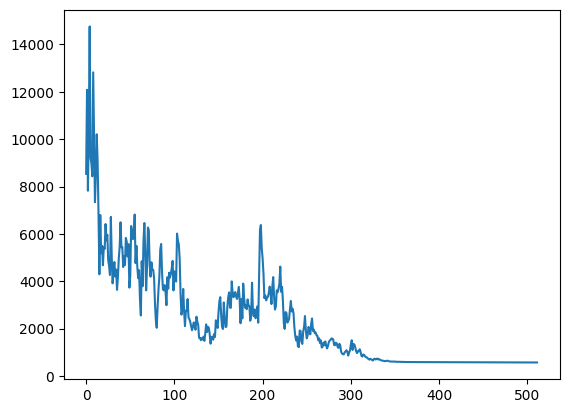

In [ ]:
import matplotlib.pyplot as plt
plt.plot(losses)

In [ ]:
torch.manual_seed(2)
xb, yb = get_batch(train_data)
decode(xb[0].tolist())

"s of York fetch down the head,\nYour father's head, which Clifford placed there;\nInstead whereof let this supply the room:\nMeasur"